# Ranking Stage: Gradient-Boosted Trees (LightGBM)

**Recap of the two-stage architecture:**

1. **Retrieval** (notebooks 01-02): score every item with a cheap model (a dot product
   between two vectors). At our toy scale (400 items) that means scoring the whole
   catalog exhaustively — nothing gets narrowed down yet. In a real system with millions
   of items you couldn't afford that, so this same cheap scoring function is exactly what
   an approximate-nearest-neighbor index (FAISS, ScaNN, ...) would serve, to get a
   shortlist without scoring everything.
2. **Ranking** (this notebook): *here* is where the narrowing actually happens — we take
   only ALS's top ~50 candidates per user. Now that there are just 50 items to score
   instead of the whole catalog, we can afford a much more powerful, feature-rich model to
   get the *order* right. That's exactly where gradient-boosted trees shine — they handle
   nonlinear feature interactions well and don't need a huge amount of data to work.

We'll reuse the ALS retrieval model from notebook 01, take its top-50 candidates per
user, and train a **LightGBM ranker** to re-order them using extra features that ALS's
plain dot-product score doesn't capture on its own.

## Why not just run GBDT over the whole catalog?

You could, in principle, score every user against every one of the 400 items with a
tree model. But real catalogs have millions of items — scoring all of them per user
with an expensive model, per request, doesn't scale. Retrieval exists precisely so
ranking only ever has to look at a short, pre-filtered list.

## The tricky part: building a *training* set for the ranker

To train a ranker we need, for many users, a set of candidate items **with labels**
(which one did the user actually pick?) and **features**. If we used the same
train/test split as the retrieval notebooks, we'd have to peek at the test label to
create training data for the ranker — leaking the exact thing we're trying to predict.

The fix: split **again**, one level deeper.

In [12]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

import rec_utils as ru

ru.setup_plot_style()

interactions, user_prefs, item_genres, item_pop = ru.generate_synthetic_data()
train, test = ru.leave_one_out_split(interactions)      # test: the final holdout (untouched until the end)
train2, val = ru.leave_one_out_split(train)              # val: a second holdout, used only to LABEL ranker training data

n_users = interactions.user_id.max() + 1
n_items = interactions.item_id.max() + 1
n_genres = item_genres.shape[1]
item_dom_genre = item_genres.argmax(axis=1)   # observable item metadata (e.g. a genre tag) -- fine to use as a feature
# this metadata is not used to generate the synthetic data, so it is not "leaking" information from the test set
# it contains information regarding the genre of the item. This is the differernce between ALS and Item2Vec, where these latter
# models can't create a score from a brand-new item with zero interactions. However, GBDT and Two-Tower models can use this metadata
#  to create a score for a brand-new item with zero interactions.

print(f"train2: {len(train2)} rows (history)  |  val: {len(val)} rows (ranker training labels)  |  test: {len(test)} rows (final holdout)")

train2: 13800 rows (history)  |  val: 600 rows (ranker training labels)  |  test: 600 rows (final holdout)


## Step 1 — generate labeled candidates for training the ranker

For every user: train an ALS model on `train2` only (so it has never seen `val` or
`test`), take its top-50 candidates, and label whichever one matches the user's `val`
item as positive (1), everything else negative (0). If the true item didn't make the
top-50, we swap it in — otherwise the ranker would never see a single positive example
for that user.

In [13]:
CAND_K = 50

# users_items2 = train.groupby("user_id")["item_id"].apply(list).to_dict()
# item_users2  = train.groupby("item_id")["user_id"].apply(list).to_dict()
user_items2, item_users2 = ru.user_item_lists(train2) 
X2, Y2 = ru.train_als(user_items2, item_users2, n_users, n_items)

seen2 = ru.user_seen_items(train2)
item_counts2 = train2["item_id"].value_counts().reindex(range(n_items), fill_value=0)
user_activity2 = train2.groupby("user_id").size()
val_map = dict(zip(val.user_id, val.item_id))

In [ ]:
def user_genre_hist(user_id, uitems):
    '''Observable feature: the distribution of genres this user has actually
    watched so far -- computed from data, not from the hidden ground truth.
    '''
    hist = np.zeros(n_genres)
    for it in uitems.get(user_id, []):
        hist[item_dom_genre[it]] += 1
    return hist / hist.sum() if hist.sum() > 0 else hist

# example for user_id = 0
user_id = 0
user_genre_hist(user_id, user_items2) # this represents the percentage of each genre that the user has watched so far

array([0.13043478, 0.2173913 , 0.08695652, 0.2173913 , 0.13043478,
       0.        , 0.08695652, 0.13043478])

In [17]:
rows = []
for u in range(n_users):
    scores = X2[u] @ Y2.T # first we compute the ALS scores for all items for this user
    candidates = ru.rank_topn(scores, seen2.get(u, set()), CAND_K) # then we pick the top-K items that the user has not already seen

    true_item = val_map.get(u) # we also need to know the true item for this user, if it exists in the validation set
    # the true item is defined as the last item the user interacted with in the validation set, which is held out from training
    if true_item is not None and true_item not in candidates:
        # it the true item is not in the top-K candidates, we replace the last candidate with it
        candidates = candidates[:-1] + [true_item]   # guarantee a positive example exists
        # it is necessary to have at least one positive example for each user in the training data, 
        # otherwise the ranker will not learn anything useful, for the test set it won't be necessary

    genre_hist = user_genre_hist(u, user_items2) # for this user u, we compute the distribution of genres they have interacted with so far
    for rank_pos, item in enumerate(candidates):
        rows.append({
            "user_id": u,
            "item_id": item,
            "label": int(item == true_item),
            "als_score": scores[item],
            "rank_pos": rank_pos,                                  # ALS's own ordering
            "log_popularity": np.log1p(item_counts2.get(item, 0)),
            "user_activity": user_activity2.get(u, 0),
            "genre_match": genre_hist[item_dom_genre[item]],
        })

ranker_train = pd.DataFrame(rows).sort_values("user_id").reset_index(drop=True)
feature_cols = ["als_score", "rank_pos", "log_popularity", "user_activity", "genre_match"]

print(f"{len(ranker_train)} (user, candidate) rows, {ranker_train['label'].sum()} positives")
ranker_train.head()

30000 (user, candidate) rows, 600 positives


,user_id,item_id,label,als_score,rank_pos,log_popularity,user_activity,genre_match
0,0,342,0,0.890335,0,5.087596,23,0.217391
1,0,319,0,0.776763,1,3.850148,23,0.217391
2,0,103,0,0.718881,2,3.891820,23,0.217391
3,0,287,0,0.699174,3,3.637586,23,0.086957
4,0,74,0,0.692362,4,3.258097,23,0.217391


## Step 2 — train a LightGBM ranker with the LambdaRank objective

Instead of plain classification (predict 0/1 independently per row), we use
**LambdaRank**: a pairwise ranking loss that directly optimizes for getting the *order*
right within each user's candidate group — which is exactly what NDCG measures. LightGBM
needs to know where one user's candidates end and the next user's begin; that's the
`group` argument (candidate group sizes, in the same row order as the data).

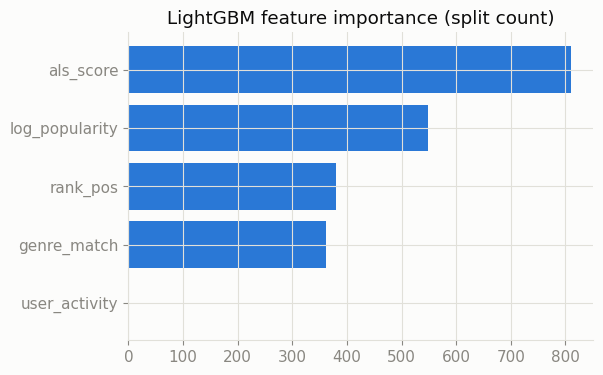

In [18]:
group_sizes = ranker_train.groupby("user_id").size().values

ranker = lgb.LGBMRanker(
    objective="lambdarank",
    n_estimators=150,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=5,
    verbosity=-1,
)
ranker.fit(ranker_train[feature_cols], ranker_train["label"], group=group_sizes)

importances = pd.Series(ranker.feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(importances.index, importances.values, color=ru.SEQUENTIAL_BLUE[3])
ax.set_title("LightGBM feature importance (split count)")
plt.show()

`als_score` naturally dominates — it's the single strongest signal — but the tree model
can still combine it with `genre_match` and `log_popularity` in ways a plain dot product
can't. Note `user_activity` barely matters here: in our synthetic data every user has
almost exactly the same number of interactions, so there's little for a tree to split on.
That's a realistic outcome of feature engineering too — not every feature you engineer
turns out to help.

## Step 3 — evaluate on the untouched test set

For the final evaluation we go back to using the **full** `train` set (all of a user's
history except the final held-out item) — this is what a real system would do at serving
time, using every bit of history it has. We retrain ALS on `train`, generate its top-50
candidates for each test user, build the same features, and let the trained ranker
reorder them.

In [19]:
user_items_full, item_users_full = ru.user_item_lists(train)
Xf, Yf = ru.train_als(user_items_full, item_users_full, n_users, n_items)

seen_full = ru.user_seen_items(train)
item_counts_full = train["item_id"].value_counts().reindex(range(n_items), fill_value=0)
user_activity_full = train.groupby("user_id").size()


def recommend_als_only(user_id, n):
    '''Retrieval alone, no re-ranking -- our point of comparison.'''
    scores = Xf[user_id] @ Yf.T
    return ru.rank_topn(scores, seen_full.get(user_id, set()), n)


def recommend_als_plus_gbdt(user_id, n):
    '''Retrieval candidates, re-ordered by the trained LightGBM ranker.'''
    scores = Xf[user_id] @ Yf.T
    candidates = ru.rank_topn(scores, seen_full.get(user_id, set()), CAND_K)
    genre_hist = user_genre_hist(user_id, user_items_full)

    feat = pd.DataFrame([{
        "als_score": scores[item],
        "rank_pos": rank_pos,
        "log_popularity": np.log1p(item_counts_full.get(item, 0)),
        "user_activity": user_activity_full.get(user_id, 0),
        "genre_match": genre_hist[item_dom_genre[item]],
    } for rank_pos, item in enumerate(candidates)])

    reranked_scores = ranker.predict(feat)
    order = np.argsort(-reranked_scores)
    return [candidates[i] for i in order][:n]


metrics_retrieval_only = ru.evaluate_recommender(recommend_als_only, train, test, k_list=(10, 20))
metrics_reranked = ru.evaluate_recommender(recommend_als_plus_gbdt, train, test, k_list=(10, 20))
ru.save_results("03_gbdt_ranking", metrics_reranked)

pd.DataFrame({
    "ALS retrieval only": metrics_retrieval_only,
    "ALS + GBDT re-ranking": metrics_reranked,
}).T

Saved results to d:\Pablo_Data\Documentos\VSCode\revolut\recommendation_algorithms\results\03_gbdt_ranking.json


,recall@10,ndcg@10,recall@20,ndcg@20
ALS retrieval only,0.108333,0.062281,0.168333,0.077169
ALS + GBDT re-ranking,0.115000,0.062243,0.190000,0.081075


## Bonus: what if you don't have genre metadata at all?

`genre_match` assumed we had a clean genre tag for every item — realistic for movies,
less realistic for a lot of real catalogs (user-generated content, marketplace listings,
anything without tidy categories). Does the ranker actually *need* that metadata, or can
we derive something similar purely from the interaction data we already have?

The idea: cluster the ALS item embeddings (`Y2`, `Yf`) themselves with k-means. This
gives every item a "pseudo-genre" label derived entirely from co-occurrence patterns —
no metadata required, the same trick notebooks 01/02 already showed recovers genre-like
structure in their PCA plots. We can then build a `pseudo_genre_match` feature exactly
the way we built `genre_match`, just swapping the true genre label for the cluster
label.

In [ ]:
from sklearn.cluster import KMeans

N_CLUSTERS = 8  # match N_GENRES purely for a fair, like-for-like comparison

kmeans2 = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=0).fit(Y2)
pseudo_genre2 = kmeans2.labels_   # unsupervised item cluster, derived only from ALS embeddings

def user_pseudo_genre_hist(user_id, uitems, item_labels, n_clusters):
    '''Same idea as user_genre_hist, but the "genre" here is a k-means cluster
    over ALS embeddings instead of a true metadata tag.
    '''
    hist = np.zeros(n_clusters)
    for it in uitems.get(user_id, []):
        hist[item_labels[it]] += 1
    return hist / hist.sum() if hist.sum() > 0 else hist


rows_free = []
for u in range(n_users):
    scores = X2[u] @ Y2.T
    candidates = ru.rank_topn(scores, seen2.get(u, set()), CAND_K)

    true_item = val_map.get(u)
    if true_item is not None and true_item not in candidates:
        candidates = candidates[:-1] + [true_item]

    pseudo_hist = user_pseudo_genre_hist(u, user_items2, pseudo_genre2, N_CLUSTERS)
    for rank_pos, item in enumerate(candidates):
        rows_free.append({
            "user_id": u,
            "item_id": item,
            "label": int(item == true_item),
            "als_score": scores[item],
            "rank_pos": rank_pos,
            "log_popularity": np.log1p(item_counts2.get(item, 0)),
            "user_activity": user_activity2.get(u, 0),
            "pseudo_genre_match": pseudo_hist[pseudo_genre2[item]],   # the metadata-free substitute
        })

ranker_train_free = pd.DataFrame(rows_free).sort_values("user_id").reset_index(drop=True)
feature_cols_free = ["als_score", "rank_pos", "log_popularity", "user_activity", "pseudo_genre_match"]
group_sizes_free = ranker_train_free.groupby("user_id").size().values

ranker_free = lgb.LGBMRanker(
    objective="lambdarank",
    n_estimators=150,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=5,
    verbosity=-1,
)
ranker_free.fit(ranker_train_free[feature_cols_free], ranker_train_free["label"], group=group_sizes_free)

pd.Series(ranker_free.feature_importances_, index=feature_cols_free, name="split count").sort_values()

user_activity           0
pseudo_genre_match    387
rank_pos              399
log_popularity        524
als_score             790
Name: split count, dtype: int32

In [8]:
kmeans_full = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=0).fit(Yf)
pseudo_genre_full = kmeans_full.labels_


def recommend_als_plus_gbdt_free(user_id, n):
    '''Same re-ranking recipe as recommend_als_plus_gbdt, but with zero
    dependence on item metadata.
    '''
    scores = Xf[user_id] @ Yf.T
    candidates = ru.rank_topn(scores, seen_full.get(user_id, set()), CAND_K)
    pseudo_hist = user_pseudo_genre_hist(user_id, user_items_full, pseudo_genre_full, N_CLUSTERS)

    feat = pd.DataFrame([{
        "als_score": scores[item],
        "rank_pos": rank_pos,
        "log_popularity": np.log1p(item_counts_full.get(item, 0)),
        "user_activity": user_activity_full.get(user_id, 0),
        "pseudo_genre_match": pseudo_hist[pseudo_genre_full[item]],
    } for rank_pos, item in enumerate(candidates)])

    reranked_scores = ranker_free.predict(feat)
    order = np.argsort(-reranked_scores)
    return [candidates[i] for i in order][:n]


metrics_reranked_free = ru.evaluate_recommender(recommend_als_plus_gbdt_free, train, test, k_list=(10, 20))

pd.DataFrame({
    "ALS retrieval only": metrics_retrieval_only,
    "ALS + GBDT (true genre_match)": metrics_reranked,
    "ALS + GBDT (metadata-free pseudo-genre)": metrics_reranked_free,
}).T

,recall@10,ndcg@10,recall@20,ndcg@20
ALS retrieval only,0.108333,0.062281,0.168333,0.077169
ALS + GBDT (true genre_match),0.115000,0.060645,0.193333,0.080500
ALS + GBDT (metadata-free pseudo-genre),0.115000,0.058848,0.168333,0.072227


The metadata-free version recovers *some* of GBDT's advantage over plain ALS retrieval,
but not all of it: Recall@10 rises from 0.108 (ALS-only) to 0.115, matching the
true-genre version exactly — but at K=20 it falls back to ALS-only's level (0.168)
rather than reaching the true-genre version's 0.193. That's an honest, mixed result, not
a disappointing one: k-means splitting items into 8 clusters from co-occurrence alone
doesn't perfectly recover the same structure as 8 true genre labels — some information
genuinely gets lost in that substitution.

The practical takeaway is still real, just more modest than "as good as metadata": **you
can manufacture a workable substitute for a metadata feature purely from a retrieval
model's own embeddings, entirely from data you already have**, and it captures a
meaningful chunk of the signal (the recall@10 result) even if it doesn't fully replicate
every gain. Real genre tags remain preferable where you actually have them — they're
cheaper (no clustering step to tune) and, importantly, they generalize immediately to a
brand-new item with zero interactions, which an embedding-based cluster fundamentally
cannot do (a new item has no ALS embedding yet, so it has no cluster either).

The re-ranked list comes from the **same 50 candidates** as the retrieval-only baseline —
this isolates exactly what re-ranking buys you: the same recall ceiling (limited by what
retrieval put in the candidate set), but better use of that ceiling because a correct
item, when present, tends to get pushed higher up.

## Takeaways

- Ranking can only reorder what retrieval already found — a two-stage system is bottlenecked
  by retrieval's *recall*, and ranking's job is *precision within that budget*.
- The gains here are modest because our synthetic features are simple; in production
  systems the ranking stage usually has access to dramatically richer features (recency,
  session context, cross-features between user and item, multiple retrieval sources
  merged together) and that's where GBDT ranking really earns its keep.
- Notice the double-split pattern (`train2`/`val` to label ranker training data,
  `train`/`test` for the final honest evaluation) — this "second-level holdout" is a
  common and easy-to-miss source of leakage in ranking pipelines.

Next: `04_retrieval_two_tower.ipynb` trains a neural retrieval model end-to-end and shows
how it compares to ALS and Item2Vec.